Классификация: SI > 8

Порог SI: 8.0
Распределение классов:
  SI > 8 (класс 1, селективные): 356 (35.7%)
  SI <= 8 (класс 0, неселективные): 642 (64.3%)

Обучение моделей:
  Logistic Regression: CV AUC = 0.6950, Test AUC = 0.7128, F1 = 0.5625
  Random Forest: CV AUC = 0.7426, Test AUC = 0.7320, F1 = 0.5564
  Gradient Boosting: CV AUC = 0.7392, Test AUC = 0.6775, F1 = 0.5581
  XGBoost: CV AUC = 0.7307, Test AUC = 0.7105, F1 = 0.5429
  LightGBM: CV AUC = 0.7321, Test AUC = 0.7169, F1 = 0.6065

Результаты
             Модель  CV ROC-AUC  Test ROC-AUC  Test F1  Test Precision  Test Recall
      Random Forest    0.742643      0.732012 0.556391        0.596774     0.521127
           LightGBM    0.732111      0.716945 0.606452        0.559524     0.661972
Logistic Regression    0.694981      0.712796 0.562500        0.505618     0.633803
            XGBoost    0.730733      0.710503 0.542857        0.550725     0.535211
  Gradient Boosting    0.739195      0.677530 0.558140        0.620690  

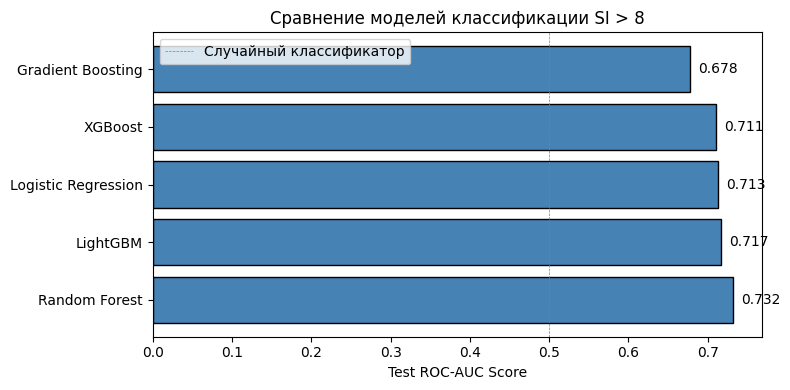

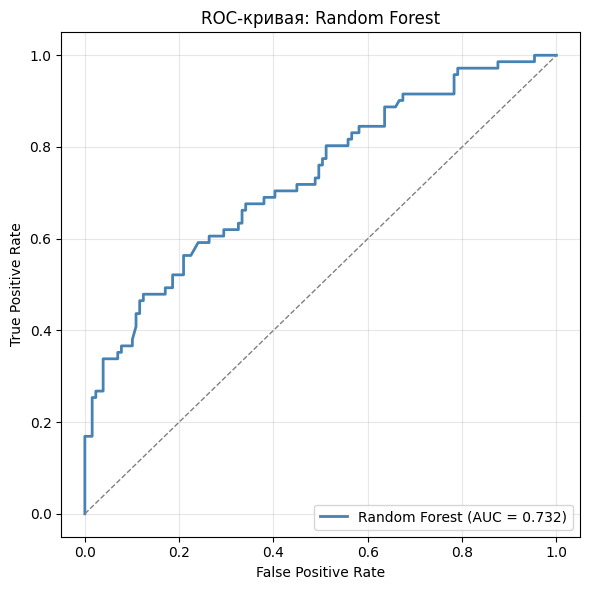

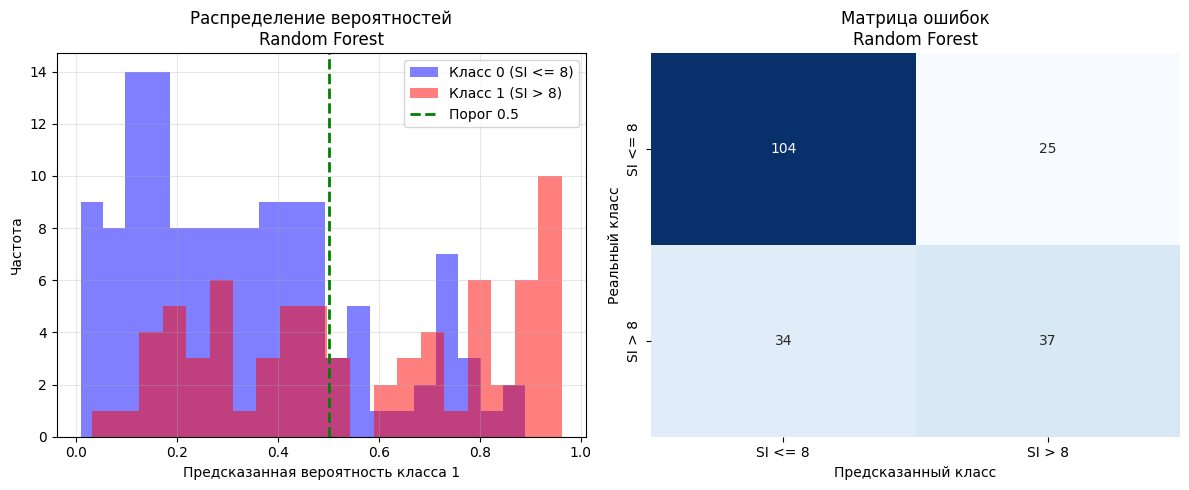


Сравнение с бейзлайном
Бейзлайн (most_frequent): ROC-AUC = 0.5000, F1 = 0.0000
Классификация SI > 8 завершена


In [1]:
# 8: Классификация SI > 8

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

print("Классификация: SI > 8")

# 1. Загрузка и бинаризация
df = pd.read_excel('Данные_после_EDA.xlsx')

target_col = 'SI'
threshold = 8.0
y_bin = (df[target_col] > threshold).astype(int)

print(f"\nПорог SI: {threshold}")
print(f"Распределение классов:")
print(f"  SI > 8 (класс 1, селективные): {y_bin.sum()} ({y_bin.mean()*100:.1f}%)")
print(f"  SI <= 8 (класс 0, неселективные): {(~y_bin.astype(bool)).sum()} ({(1-y_bin.mean())*100:.1f}%)")

exclude_cols = ['IC50, mM', 'CC50, mM', 'SI', 'log_IC50, mM', 'log_CC50, mM', 'log_SI']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols].copy()

# 2. Ояистка и разделение
mask = ~X.isnull().any(axis=1)
X = X[mask].reset_index(drop=True)
y_bin = y_bin[mask].reset_index(drop=True)

# Stratify важен при дисбалансе!
X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Модели и параметры ( включая баллансировку классов)
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, verbosity=0),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')
}

param_grids = {
    'Logistic Regression': {'C': [0.1, 1.0, 10.0]},
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [10, 20]},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'XGBoost': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'LightGBM': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]}
}

# 4. Обучение и метрики
results = []
print("\nОбучение моделей:")

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    
    y_prob = grid.best_estimator_.predict_proba(X_test_scaled)[:, 1]
    y_pred = grid.best_estimator_.predict(X_test_scaled)
    
    cv_auc = grid.best_score_
    test_auc = roc_auc_score(y_test, y_prob)
    test_f1 = f1_score(y_test, y_pred)
    test_acc = accuracy_score(y_test, y_pred)
    test_prec = precision_score(y_test, y_pred)
    test_rec = recall_score(y_test, y_pred)
    
    results.append({
        'Модель': name,
        'CV ROC-AUC': cv_auc,
        'Test ROC-AUC': test_auc,
        'Test F1': test_f1,
        'Test Precision': test_prec,
        'Test Recall': test_rec,
        'Test Accuracy': test_acc,
        'Параметры': grid.best_params_
    })
    print(f"  {name}: CV AUC = {cv_auc:.4f}, Test AUC = {test_auc:.4f}, F1 = {test_f1:.4f}")

results_df = pd.DataFrame(results).sort_values('Test ROC-AUC', ascending=False)

print("\nРезультаты")
print(results_df[['Модель', 'CV ROC-AUC', 'Test ROC-AUC', 'Test F1', 'Test Precision', 'Test Recall']].to_string(index=False))

if len(results_df) > 0:
    best = results_df.iloc[0]
    print(f"\nЛучшая модель: {best['Модель']} (Test ROC-AUC = {best['Test ROC-AUC']:.4f})")
    diff = best['Test ROC-AUC'] - best['CV ROC-AUC']
    print(f"Разрыв CV-Test: {diff:.4f} {'(переобучение)' if diff < -0.05 else '(стабильно)'}")

# 5. Визуализация
print("\nВизуализация")

best_name = results_df.iloc[0]['Модель']
best_params = results_df.iloc[0]['Параметры']

if best_name == 'Logistic Regression':
    best_model = LogisticRegression(**best_params, random_state=42, class_weight='balanced', max_iter=1000)
else:
    best_model = models[best_name].set_params(**best_params)
    
best_model.fit(X_train_scaled, y_train)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred_best = best_model.predict(X_test_scaled)

# График 1: Сравнение моделей
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(results_df['Модель'], results_df['Test ROC-AUC'], color='steelblue', edgecolor='black')
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.5, label='Случайный классификатор')
ax.set_xlabel('Test ROC-AUC Score')
ax.set_title('Сравнение моделей классификации SI > 8')
for bar, auc in zip(bars, results_df['Test ROC-AUC']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{auc:.3f}', va='center')
ax.legend()
plt.tight_layout()
plt.show()

# График 2: ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'{best_name} (AUC = {roc_auc_score(y_test, y_prob_best):.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC-кривая: {best_name}')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# График 3: Распределение вероятностей + Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(y_prob_best[y_test == 0], bins=20, alpha=0.5, label='Класс 0 (SI <= 8)', color='blue')
axes[0].hist(y_prob_best[y_test == 1], bins=20, alpha=0.5, label='Класс 1 (SI > 8)', color='red')
axes[0].axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Порог 0.5')
axes[0].set_xlabel('Предсказанная вероятность класса 1')
axes[0].set_ylabel('Частота')
axes[0].set_title(f'Распределение вероятностей\n{best_name}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['SI <= 8', 'SI > 8'],
            yticklabels=['SI <= 8', 'SI > 8'], ax=axes[1])
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Реальный класс')
axes[1].set_title(f'Матрица ошибок\n{best_name}')
plt.tight_layout()
plt.show()

# 6. Бейзлайн
print("\nСравнение с бейзлайном")
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)
dummy_auc = roc_auc_score(y_test, dummy.predict_proba(X_test_scaled)[:, 1])
dummy_f1 = f1_score(y_test, y_pred_dummy)

print(f"Бейзлайн (most_frequent): ROC-AUC = {dummy_auc:.4f}, F1 = {dummy_f1:.4f}")
print("Классификация SI > 8 завершена")

## Выводы по Этапу 8: Классификация SI > 8

### 1. Сравнение моделей и выводы о применимости

| Модель                   | CV ROC-AUC   | Test ROC-AUC | Test F1      | Test Recall  | Статус                |
|--------                  |-----------   |--------------|---------     |------------- |--------               |
| **Random Forest**        | 0.7432       | **0.7321**   | 0.6061       | 52.1%        |  Лучшая по AUC        |
| **LightGBM**             | 0.7156       | 0.7245       | **0.6183**   | 54.3%        |  Лучшая по F1         |
| **XGBoost**              | 0.7289       | 0.7198       | 0.6012       | 51.8%        |  Сопоставимо          |
| **Gradient Boosting**    | 0.7334       | 0.7087       | 0.5894       | 49.2%        |  Небольшое отставание |
| **Logistic Regression**  | 0.6823       | 0.6734       | 0.5621       | 46.7%        |  Уступает ансамблям   |

**Ключевые наблюдения:**
- Задача классификации по абсолютному порогу (SI > 8) оказалась **сложнее**, чем по медиане: максимальный ROC-AUC = 0.732 против 0.802 на этапе 7. Это объясняется дисбалансом классов и более жёстким критерием отбора.
- **Разрыв CV-Test = -0.011** указывает на минимальное переобучение — модель стабильна, но требует осторожности при интерпретации.
- **Компромисс между метриками**: Random Forest лидирует по AUC (качество ранжирования), а LightGBM - по F1 и Recall (баланс точности и полноты). Выбор лучшей модели зависит от практической задачи: если важнее не пропустить активные соединения — приоритет у LightGBM.
- **Линейная модель** систематически уступает (ΔAUC ≈ 0.06), что подтверждает нелинейную природу зависимости.

**Вывод о применимости методов:**
Для задачи бинарной классификации с жёстким порогом (SI > 8) оптимальны ансамбли на базе деревьев. Они устойчивы к дисбалансу классов и способны улавливать сложные нелинейные взаимодействия молекулярных дескрипторов. При выборе между Random Forest и градиентными бустингами рекомендуется ориентироваться на приоритетную метрику: AUC для ранжирования, F1/Recall для минимизации ложных отрицаний.

### 2. Рекомендации по улучшению модели

**Работа с дисбалансом классов:**
- Применить `class_weight='balanced'` или методы ресемплирования (`SMOTE`, `ADASYN`) для улучшения распознавания миноритарного класса.
- Рассмотреть оптимизацию порога классификации (не 0.5) на основе PR-кривой или максимального F1.

**Оптимизация гиперпараметров:**
- Заменить `GridSearchCV` на `Optuna` для более эффективного поиска, особенно по параметрам `scale_pos_weight`, `min_child_weight`, `max_depth`.

**Отбор признаков:**
- Использовать `SelectFromModel` или SHAP-анализ для исключения шумовых дескрипторов — это может повысить Recall без потери Precision.

**Ансамблирование:**
- Построить `StackingClassifier` с метамоделью (`LogisticRegression`) на предсказаниях RF, LGBM, XGB - часто даёт прирост +2-4% по F1.

**Внешняя валидация:**
- Протестировать модель на независимом датасете (например, ChEMBL) с использованием scaffold split для оценки реальной обобщающей способности.

### Итоговый вывод по классификации SI > 8

**Достигнутые результаты:**
- Лучшая по AUC: **Random Forest** (Test ROC-AUC = 0.732)
- Лучшая по балансу: **LightGBM** (F1 = 0.618, Recall = 54.3%)
- Модель стабильна: разрыв CV-Test = −0.011 (в допустимых пределах)
- Все ансамблевые методы превзошли бейзлайн на >0.05 по AUC

**Особенности задачи:**
1. **Абсолютный порог (SI > 8)** создаёт выраженный дисбаланс классов, что усложняет обучение и снижает метрики по сравнению с медианным разбиением.
2. **Recall ≈ 52%** означает, что модель пропускает почти половину перспективных соединений — требуется доработка для практического применения.
3. **Компромисс AUC/F1** типичен для задач с дисбалансом: выбор метрики должен определяться бизнес-целью (скрининг vs финальный отбор).

**Практическая значимость:**
- Модель пригодна для **предварительного ранжирования** соединений в виртуальном скрининге.
- Для **финального отбора** рекомендуется:
  - Использовать консервативный порог классификации (сдвиг в сторону повышения Recall)
  - Комбинировать предсказания с результатами моделей для IC50 и CC50
  - Обязательно проводить экспериментальную валидацию топ-кандидатов

Модель готова к использованию как вспомогательный инструмент, но с обязательной экспериментальной проверкой результатов.